In [1]:
import json
from typing import Any, cast

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import v2

from src import video_transforms as vt
from src.configs import get_avail_splits, get_class_list, set_seed
from src.models import avail_models, get_model, norm_vals
from src.run_types import AVAIL_SPLITS, RUNS_PATH, SEED, SRC_ROOT, OG_Sampler
from src.testing import test_topk_clsrep
from src.utils import plt_display_grid
from src.video_dataset import VideoDataset, get_wlasl_info

In [2]:
set_seed(SEED)

## Setup

### Model

Available models:

In [3]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv2_S_e
8: MViTv1_B
9: MViTv2_S_16x4
10: MViTv2_S_16x4_e
11: MViTv2_B_32x3
12: MViTv2_B_32x3_r


Chosen model: 

In [4]:
model_name = av_models[0]
print(model_name)

S3D


Norm values: 

In [5]:
model_info = norm_vals(model_name)
print(model_info)

mean=(0.43216, 0.394666, 0.37645) std=(0.22803, 0.22145, 0.216989)


### Dataset

Available splits

In [6]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100_worst
asl1000
asl2000_cutoff_9
asl100_bottom
asl100
asl300_cutoff_9
asl1000_cutoff_9
asl2000
asl100_cutoff_9
asl300


Chosen split, and set

In [7]:
split_name: AVAIL_SPLITS = "asl100"
print(split_name)

asl100


Dataset info

In [8]:
test_info = get_wlasl_info(split_name, set_name="test")
print(test_info)


{'root': PosixPath('/home/luke/Code/SLR/data/WLASL/WLASL2000'), 'labels': PosixPath('/home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100'), 'label_suff': 'fixed_frange_bboxes.json', 'set_name': 'test'}


Class list

In [9]:
class_list = get_class_list()
print(len(class_list))

2000


#### Data Sets

one with centre crop and one with bounding box crop and resize


In [10]:
norm_dict = norm_vals(model_name)
print(norm_dict)
num_frames = 32
frame_size = 224
batch_size = 1

sampler = vt.get_sampler(OG_Sampler(target_length=num_frames))

mean=(0.43216, 0.394666, 0.37645) std=(0.22803, 0.22145, 0.216989)


## Shared final transform

In [11]:
final_transform = v2.Compose(
    [
        v2.Lambda(vt._normalize_to_float),
        v2.Normalize(mean=norm_dict.mean, std=norm_dict.std),
        v2.Lambda(vt._permute_time_channel),
    ]
)

## Centre Crop

Transform

In [12]:
cc_tranform = v2.Compose([sampler, v2.CenterCrop(frame_size), final_transform])

Dataset

In [13]:
cc_test_set = VideoDataset(
    set_info=test_info,
    transforms=cc_tranform,
)

Dataloader

In [14]:
cc_loader = DataLoader(
    cc_test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

## Bounding box Crop and resize

Transforms

In [15]:
def scale_and_pad(frames: torch.Tensor, size: int) -> torch.Tensor:
    """Scale the larger side to frame size, then pad boundaries. Assumes T C H W"""
    _, _, H, W = frames.shape

    # Scale so the LARGER side hits `size`, preserving aspect ratio
    if H >= W:
        new_H, new_W = size, round(W * size / H)
    else:
        new_H, new_W = round(H * size / W), size

    # torchvision resize handles T C H W directly
    resiz = v2.Resize(
        [new_H, new_W], interpolation=v2.InterpolationMode.BICUBIC, antialias=True
    )

    # Distribute leftover pixels evenly; odd remainder goes to bottom/right
    pad_H = size - new_H
    pad_W = size - new_W
    top, bottom = pad_H // 2, pad_H - pad_H // 2
    left, right = pad_W // 2, pad_W - pad_W // 2

    return F.pad(resiz(frames), (left, right, top, bottom))  # F.pad: W then H

In [16]:
bbc_transform = v2.Compose([sampler, lambda x: scale_and_pad(x, frame_size), final_transform])

Dataset

In [17]:
bbc_test_set = VideoDataset(
    set_info=test_info,
    transforms=bbc_transform,
    item_transforms=vt._crop_frames,
)

In [18]:
bbc_loader = DataLoader(
    bbc_test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [19]:
print(len(bbc_loader))
print(bbc_test_set.num_classes)

258
100


## Examine frames

In [20]:
iter_cc = iter(cc_loader)
iter_bbc = iter(bbc_loader)

In [21]:
sample_cc = next(iter_cc)
sample_bbc = next(iter_bbc)

In [22]:
cc_f = sample_cc['frames']
print(cc_f.shape)

bbc_f = sample_bbc['frames']
print(bbc_f.shape)

torch.Size([1, 3, 32, 224, 224])
torch.Size([1, 3, 32, 224, 224])


In [23]:
def prep_frames_and_label(
    sample: dict[str, int | torch.Tensor],
) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'

    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3:
        frames = frames.permute(1, 0, 2, 3)  # swap T and C
    return frames, int(label_num.squeeze())

# Looking at what the machine sees 


In [24]:
figsize = (2,2)

## Centre Crop

frames: torch.Size([32, 3, 224, 224])
Class: book


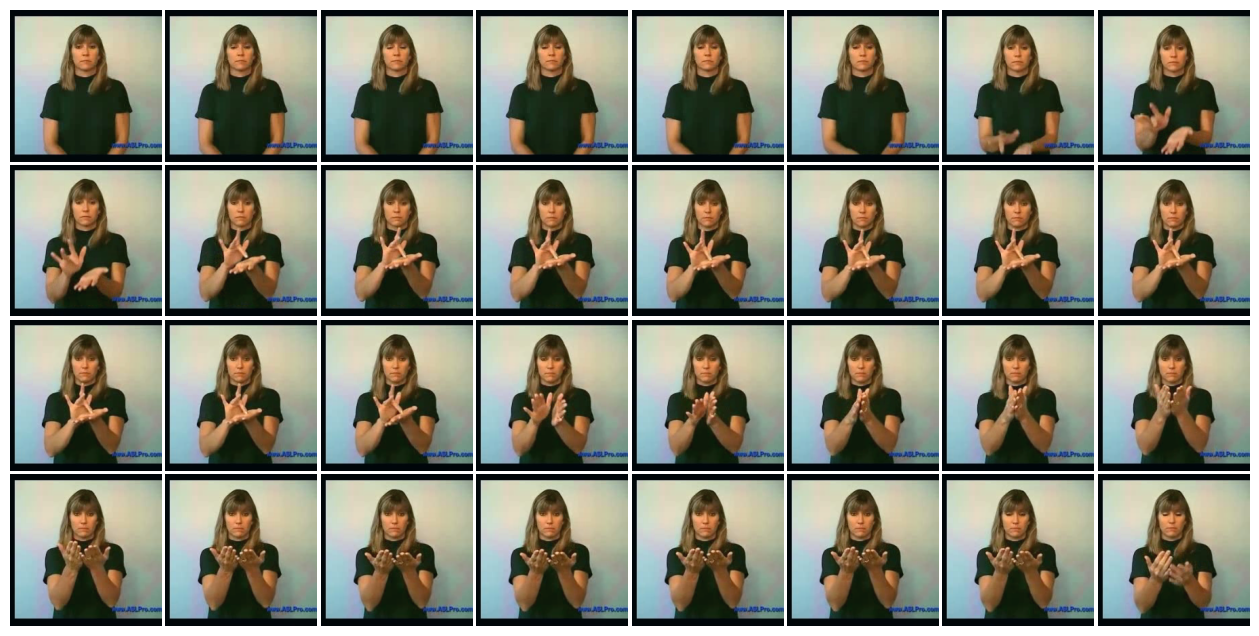

In [25]:
frames_cc, label_num = prep_frames_and_label(sample_cc)
print(f"frames: {frames_cc.shape}")
print(f'Class: {class_list[label_num]}')
plt_display_grid(frames_cc, num_frames, size=figsize)

## Bounding box crop

frames: torch.Size([32, 3, 224, 224])
Class: book


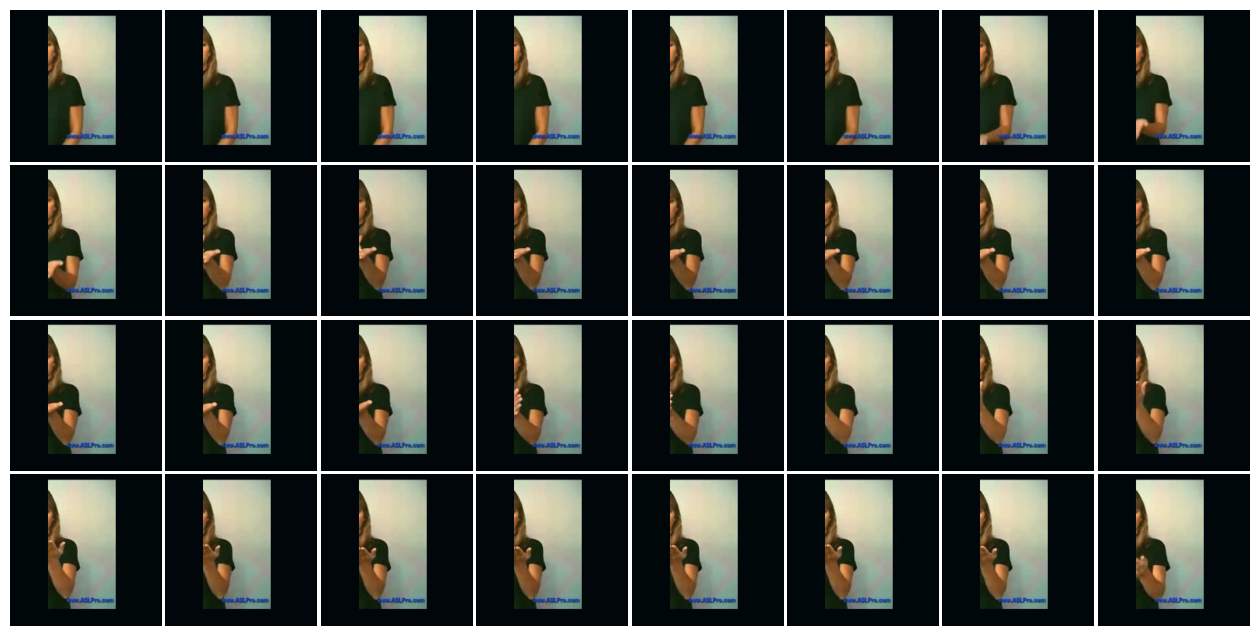

In [26]:
frames_bbc, label_num = prep_frames_and_label(sample_bbc)
print(f"frames: {frames_bbc.shape}")
print(f'Class: {class_list[label_num]}')
plt_display_grid(frames_bbc, num_frames, size=figsize)

# Time to test

In [27]:

model = get_model(model_name, cc_test_set.num_classes, drop_p= 0.5)


In [28]:
def sort_dict(d: dict[str, Any]) -> dict[str, Any]:
    return {key: value for key, value in sorted(d.items(), key=lambda x: x[0])}

In [29]:
exps_dict_path = SRC_ROOT / "results/saicist/wlasl_saicist.json"
with open(exps_dict_path) as f:
    exps_dict = json.load(f)
exps_dict = cast(dict[str, dict[str, list[str]]], exps_dict)

for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)

In [30]:
runs_dir = RUNS_PATH / split_name
exp_no = exps_dict[split_name][model_name][0]
checkpoint_path = runs_dir / f"{model_name}_exp{exp_no}" / "checkpoints" / "best.pth"
checkpoint = torch.load(checkpoint_path, weights_only=True)

FileNotFoundError: [Errno 2] No such file or directory: '/home/luke/Code/SLR/src/runs/asl100/S3D_exp051/checkpoints/best.pth'

In [31]:
model.load_state_dict(checkpoint)

NameError: name 'checkpoint' is not defined

Centre crop

In [ ]:

topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
		model=model,
		test_loader=cc_loader,
		verbose=False,
	)

Bounding box crop

In [ ]:

topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
		model=model,
		test_loader=bbc_loader,
		verbose=False,
	)

Conclusion:

no real impact of the bbox crop